<a href="https://colab.research.google.com/github/renee192/deeplearning-sitting-posture-classification/blob/main/1D_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import zipfile
from google.colab import drive

In [2]:
def set_seed_strict(seed=42):
    # 1. Standard Library Seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # 2. GPU Seeds
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# **Data Loading & Data Preparation**



In [3]:
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/sitting-posture-keyjoint-dataset.zip'
csv = {}

with zipfile.ZipFile(zip_path, 'r') as z:
    # Get a list of all files in the zip
    all_files = z.namelist()

    # Filter for only CSV files
    csv_files = [f for f in all_files if f.endswith('.csv') and not f.startswith('__MACOSX')]

    for csv_path in csv_files:
        with z.open(csv_path) as f:
            # Use the filename as the key
            file_name = csv_path.split('/')[-1]
            csv[file_name] = pd.read_csv(f)
            print(f"Loaded: {csv_path}")

Mounted at /content/drive
Loaded: keyjoint_test_dataset/keypoint_test_data.csv
Loaded: keyjoint_train_dataset/keypoint_train_data.csv
Loaded: keyjoint_valid_dataset/keypoint_valid_data.csv


## **Load Datasets**

In [4]:
train_df = csv['keypoint_train_data.csv']
valid_df = csv['keypoint_valid_data.csv']
test_df = csv['keypoint_test_data.csv']

In [5]:
train_df['cat_id'] = train_df['cat_id'] - 1
valid_df['cat_id'] = valid_df['cat_id'] - 1
test_df['cat_id'] = test_df['cat_id'] - 1

train_df.head()

,image_id,nose_x,nose_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,left_ear_x,left_ear_y,right_ear_x,...,right_hip_y,left_knee_x,left_knee_y,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,cat_id
0,0,381.16638,125.74674,381.16638,114.56327,373.18173,114.56327,344.43698,129.74083,346.83237,...,399.74170,504.13004,388.55823,504.13004,394.94880,526.48700,553.11490,527.28550,553.1149,0
1,1,368.70316,200.29625,373.50010,186.69975,371.90112,187.49956,409.47720,187.49956,410.27667,...,436.23526,259.17288,443.43335,349.51538,372.25177,328.72860,556.20420,362.30722,524.2125,1
2,2,254.82500,367.37567,227.67700,378.56620,227.67700,378.56620,219.69230,471.28780,219.69230,...,-1.00000,-1.00000,-1.00000,-1.00000,-1.00000,-1.00000,-1.00000,-1.00000,-1.0000,1
3,3,423.61874,145.82068,431.61090,129.04533,426.81564,129.04533,469.17392,129.84416,473.16998,...,419.01930,192.64620,381.47446,298.14230,403.84160,148.68947,582.77875,256.58322,536.4468,1
4,4,241.43028,215.02322,243.82657,201.42589,242.22903,203.02559,278.97250,199.82622,279.77130,...,451.77676,137.58995,457.37570,223.85728,387.78934,203.08922,563.75480,239.03394,539.7595,1


In [6]:
def safely_normalize_coordinates(df, scaler=None):
    df_normalized = df.copy()

    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    df_normalized[coord_cols] = df_normalized[coord_cols].replace(-1.0, np.nan)

    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized[coord_cols] = scaler.fit_transform(df_normalized[coord_cols])

    else:
        df_normalized[coord_cols] = scaler.transform(df_normalized[coord_cols])

    df_normalized[coord_cols] = df_normalized[coord_cols].fillna(-1.0)

    return df_normalized, scaler


In [7]:
train_df_norm, fitted_scaler = safely_normalize_coordinates(train_df)
valid_df_norm, _ = safely_normalize_coordinates(valid_df, scaler=fitted_scaler)
test_df_norm, _ = safely_normalize_coordinates(test_df, scaler=fitted_scaler)

## **Dataset Class**

In [8]:
class KeypointDataset(Dataset):
  def __init__(self, df):
    X_np = df.drop(['image_id', 'cat_id'], axis =1).values
    y_np = df['cat_id'].values

    # Reshape from (N, 34) to (N, 17, 2)
    N = X_np.shape[0]
    X_reshape = X_np.reshape(N, 17, 2)

    X_transpose = np.transpose(X_reshape, (0, 2, 1))

    # Convert to tensors
    self.X = torch.tensor(X_transpose, dtype=torch.float32)
    self.y = torch.tensor(y_np,dtype=torch.float32).unsqueeze(1)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [9]:
train_dataset = KeypointDataset(train_df_norm)
valid_dataset = KeypointDataset(valid_df_norm)
test_dataset = KeypointDataset(test_df_norm)

##**Batch Loading with DataLoader**

In [10]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [11]:
X_batch, y_batch = next(iter(train_loader))
print("Batch X shape:", X_batch.shape)
print("Batch y shape:", y_batch.shape)

Batch X shape: torch.Size([64, 2, 17])
Batch y shape: torch.Size([64, 1])


#**Model Class**

In [12]:
class CNN1d(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv1d(in_channels=2, out_channels=32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm1d(32)
    self.pool1 = nn.MaxPool1d(kernel_size=2)

    self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm1d(64)
    self.pool2 = nn.MaxPool1d(kernel_size=2)

    self.global_avg_pool = nn.AdaptiveAvgPool1d(1)

    self.fc1 = nn.Linear(64, 32)
    self.dropout = nn.Dropout(p=0.6)
    self.fc2 = nn.Linear(32, 1)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = F.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = self.bn2(x)
    x = F.relu(x)
    x = self.pool2(x)

    x = self.global_avg_pool(x)
    x = torch.flatten(x, 1)

    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout(x)

    x = self.fc2(x)

    return x

In [13]:
model = CNN1d()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(model)

CNN1d(
  (conv1): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_avg_pool): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [14]:
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-3)

In [15]:
def calculate_accuracy(y_pred, y_true):
    # Apply sigmoid to the raw logits to get probabilities
    probabilities = torch.sigmoid(y_pred)
    # Round probabilities to 0 or 1
    predicted_classes = torch.round(probabilities)
    # Count how many match the true labels
    correct = (predicted_classes == y_true).sum().float()
    # Calculate percentage
    return correct / y_true.shape[0]

In [16]:
train_losses = []
train_accs = []
valid_losses = []
valid_accs = []

epochs = 50

best_val_loss = float('inf')
patience = 5
patience_count = 0
checkpoint_path = "/content/drive/MyDrive/best_model1.pth"

for epoch in range(epochs):
  model.train()

  train_loss = 0.0
  train_acc = 0.0

  for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = loss_function(predictions, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
        train_acc += calculate_accuracy(predictions, y_batch).item()

  avg_train_loss = train_loss / len(train_loader)
  avg_train_acc = train_acc / len(train_loader)

  model.eval()
  valid_loss = 0.0
  valid_acc = 0.0

  with torch.no_grad():
      for X_batch, y_batch in valid_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)

          predictions = model(X_batch)
          loss = loss_function(predictions, y_batch)

          valid_loss += loss.item()
          valid_acc += calculate_accuracy(predictions, y_batch).item()

  avg_valid_loss = valid_loss / len(valid_loader)
  avg_valid_acc = valid_acc / len(valid_loader)

  train_losses.append(avg_train_loss)
  train_accs.append(avg_train_acc)
  valid_losses.append(avg_valid_loss)
  valid_accs.append(avg_valid_acc)

  print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"| Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% "
          f"| Valid Loss: {avg_valid_loss:.4f} | Valid Acc: {avg_valid_acc*100:.2f}%")

  if avg_valid_loss < best_val_loss:
      print(f"Valid loss improved. Saving checkpoint to {checkpoint_path}")
      best_val_loss = avg_valid_loss
      patience_counter = 0
      torch.save(model.state_dict(), checkpoint_path)
  else:
      patience_counter += 1
      print(f"Patience: {patience_counter}/{patience}")
      if patience_counter >= patience:
          print("Early Stopping triggered")
          break

print("Training Complete.")

Epoch [01/50] | Train Loss: 0.6914 | Train Acc: 53.52% | Valid Loss: 0.6859 | Valid Acc: 58.54%
Valid loss improved. Saving checkpoint to /content/drive/MyDrive/best_model1.pth
Epoch [02/50] | Train Loss: 0.6642 | Train Acc: 60.51% | Valid Loss: 0.6630 | Valid Acc: 66.49%
Valid loss improved. Saving checkpoint to /content/drive/MyDrive/best_model1.pth
Epoch [03/50] | Train Loss: 0.6506 | Train Acc: 64.58% | Valid Loss: 0.6441 | Valid Acc: 69.50%
Valid loss improved. Saving checkpoint to /content/drive/MyDrive/best_model1.pth
Epoch [04/50] | Train Loss: 0.6386 | Train Acc: 66.70% | Valid Loss: 0.6319 | Valid Acc: 69.10%
Valid loss improved. Saving checkpoint to /content/drive/MyDrive/best_model1.pth
Epoch [05/50] | Train Loss: 0.6344 | Train Acc: 66.22% | Valid Loss: 0.6248 | Valid Acc: 68.19%
Valid loss improved. Saving checkpoint to /content/drive/MyDrive/best_model1.pth
Epoch [06/50] | Train Loss: 0.6298 | Train Acc: 66.43% | Valid Loss: 0.6191 | Valid Acc: 68.19%
Valid loss improved

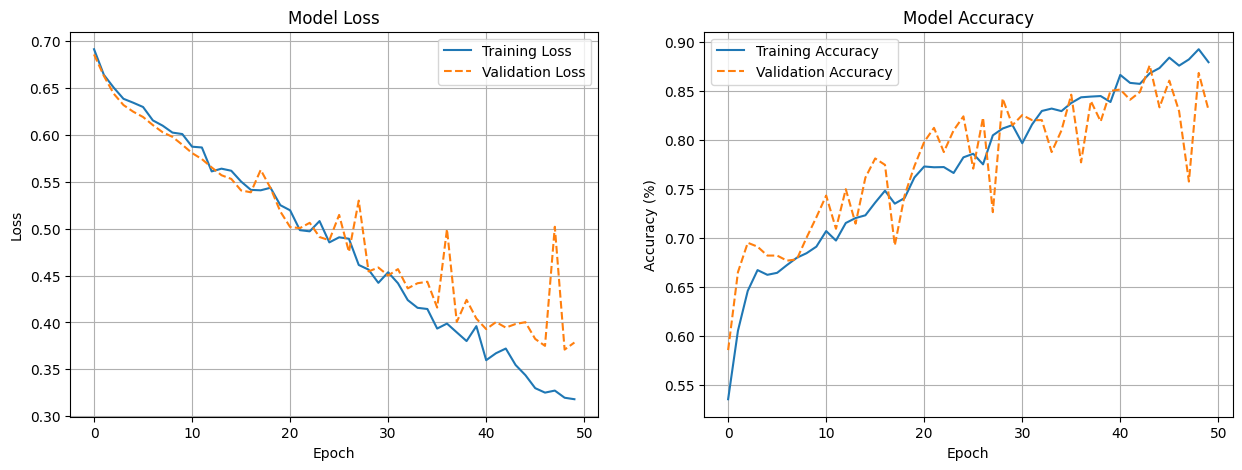

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(valid_losses, label='Validation Loss', linestyle='--')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(valid_accs, label='Validation Accuracy', linestyle='--')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.show()

In [18]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model1.pth"))
model.eval()
print("Best model loaded")

final_preds = []
final_true = []

with torch.no_grad():
    for X_batch, y_batch in valid_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        out = model(X_batch)
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()

        final_preds.extend(preds.cpu().numpy())
        final_true.extend(y_batch.cpu().numpy())

print(classification_report(final_true, final_preds, target_names=["Good Posture", "Bad Posture"], zero_division=0))

Best model loaded
              precision    recall  f1-score   support

Good Posture       0.89      0.83      0.86        88
 Bad Posture       0.85      0.90      0.87        91

    accuracy                           0.87       179
   macro avg       0.87      0.87      0.87       179
weighted avg       0.87      0.87      0.87       179

